In [1]:
import os
import sys
import jax
import jax.numpy as np
import jax.tree as jtu

# Basic jax import
jax.config.update("jax_enable_x64", True)

# Check if running on remote, and set directory to where notebook is run
if jax.devices()[0].platform == "gpu":
    os.chdir("code/amigo_project/notebooks/calibration")
else:
    os.chdir("/Users/louis/PhD/Software/sandbox/amigo_project/notebooks/calibration")

# Add parent directories
paths = [os.path.abspath(os.path.join(os.getcwd(), path)) for path in ["..", "../.."]]
for path in paths:
    if path not in sys.path:
        sys.path.insert(0, path)

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
        
# Plotting set up
%matplotlib inline
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 120

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]


inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)


# Load our model and fitted visibilities

In [3]:
from amigo.optical_models import AMIOptics
from amigo.vis_models import LogVisModel

# Load the cached states
file_path = "../../GPU_files"


# Load the cached states
load_dict = lambda x: np.load(f"{file_path}/{x}.npy", allow_pickle=True).item()
cal_values = load_dict("v_0.0.10/calibration")
vis_basis = load_dict("v_0.0.10/vis_basis")

# GO
program = "GO1843"
fit = load_dict(f"results/{program}/vis_fit")

n_basis = fit.pop("n_basis")
optics = AMIOptics(psf_upsample=1)
vis_model = LogVisModel(vis_basis, n_basis=n_basis)

# Get the average aberrations per filter for the Kernel visibilities

In [4]:
# Sort the aberration values by their filter
filters = sorted(list(set([fit_values["filter"] for fit_values in fit.values()])))
aberrations = {k: [] for k in filters}
for exp_key, fit_values in fit.items():
    aberrations[fit_values["filter"]].append(fit_values["aberrations"])

# Get the mean aberration value per filter
leaf_fn = lambda x: isinstance(x, list)
list_mean = lambda x: np.array(x).mean(0)
aberrations = jtu.map(lambda x: list_mean(x), aberrations, is_leaf=leaf_fn)

# Calculate the Kernel visibilities

In [5]:
from amigo.stats import svd
from amigo.vis_calibration import vis_jac_fn
from amigo.core_models import ModelParams
from amigo.misc import tqdm
import dLux.utils as dlu


thresh = 1e-12
kernel_outputs = {}
for filt in tqdm(filters):
    optics = optics.set("defocus", cal_values["defocus"][filt])

    model_params = ModelParams(
        {
            # Note we dont need to marginalise over positions - its subsumed by abbs
            "defocus": cal_values["defocus"][filt],
            "spectra": np.zeros(1),
            "fluxes": np.zeros(1),
            "abb_coeffs": aberrations[filt],
        }
    )

    jac_fn = lambda X: vis_jac_fn(X, (optics, vis_model, filt))
    amp_fn, phase_fn = lambda X: jac_fn(X)[0], lambda X: jac_fn(X)[1]
    J_amp = model_params.jacfwd(amp_fn, n_batch=30)
    J_phase = model_params.jacfwd(phase_fn, n_batch=30)

    # Get the Jacobian decompositions
    u_amp, s_amp, vh_amp = svd(J_amp)
    u_phase, s_phase, vh_phase = svd(J_phase)

    n_amp = len(s_amp) - np.sum(s_amp < thresh)
    n_phase = len(s_phase) - np.sum(s_phase < thresh)

    # NOTE: After deleting the rows/cols, the matrix is NOT symmetric, so its inverse
    # is NOT the same as the transpose.
    kernel_outputs[filt] = {
        "kernel_mats": {
            "amplitudes": u_amp[:, n_amp:].T,
            "phases": u_phase[:, n_phase:].T,
        },
        "proj_mats": {
            "amplitudes": u_amp[:, :len(s_amp)].T,
            "phases": u_phase[:, :len(s_phase)].T,
        },
        "J_mats": {
            "amplitudes": J_amp,
            "phases": J_phase,
        },
        "singular_vals": {
            "amplitudes": s_amp,
            "phases": s_phase,
        },
    }

  0%|          | 0/3 [00:00<?, ?it/s]

E1014 01:21:08.018101  689046 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %reduce-window.1 = f64[9,32,32]{2,1,0} reduce-window(%broadcast.490, %constant.5052), window={size=1x32x32 stride=1x32x32}, to_apply=%region_9.16

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E1014 01:21:08.891522  688931 slow_operation_alarm.cc:140] The operation took 1.881894s
Constant folding an instruction is taking > 1s:

  %reduce-window.1 = f64[9,32,32]{2,1,0} reduce-window(%broadcast.490, %constant.5052), window={size=1x32x32 stride=1x32x32}, to_apply=%region_9.16

This isn't necessarily a bug; constant-folding is inherent

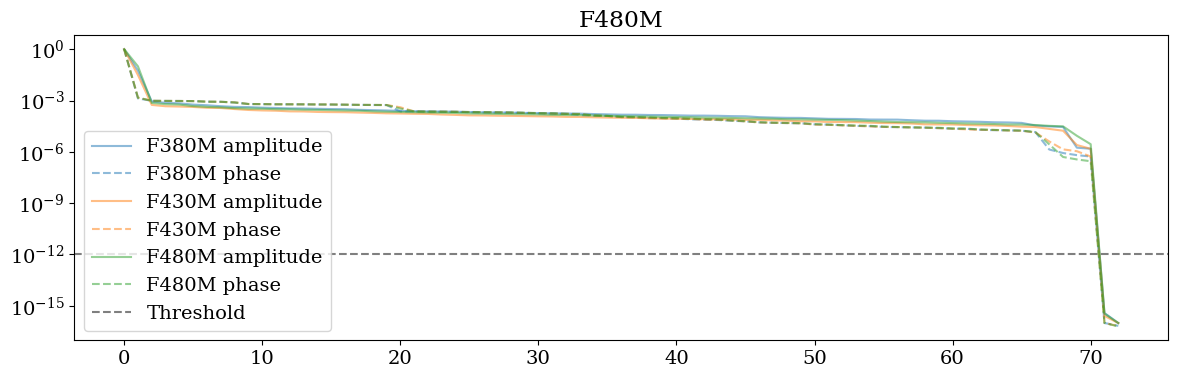

In [6]:
plt.figure(figsize=(12, 4))
for i, filt in enumerate(filters):
    s_amp = kernel_outputs[filt]["singular_vals"]["amplitudes"]
    s_phase = kernel_outputs[filt]["singular_vals"]["phases"]

    plt.title(filt)
    plt.plot(s_amp, label=f"{filt} amplitude", c=f"C{i}", alpha=0.5)
    plt.plot(s_phase, label=f"{filt} phase", ls="--", c=f"C{i}", alpha=0.5)
    plt.yscale("log")

plt.axhline(thresh, ls="--", c="k", alpha=0.5, label="Threshold")
plt.legend()
plt.tight_layout()
plt.show()

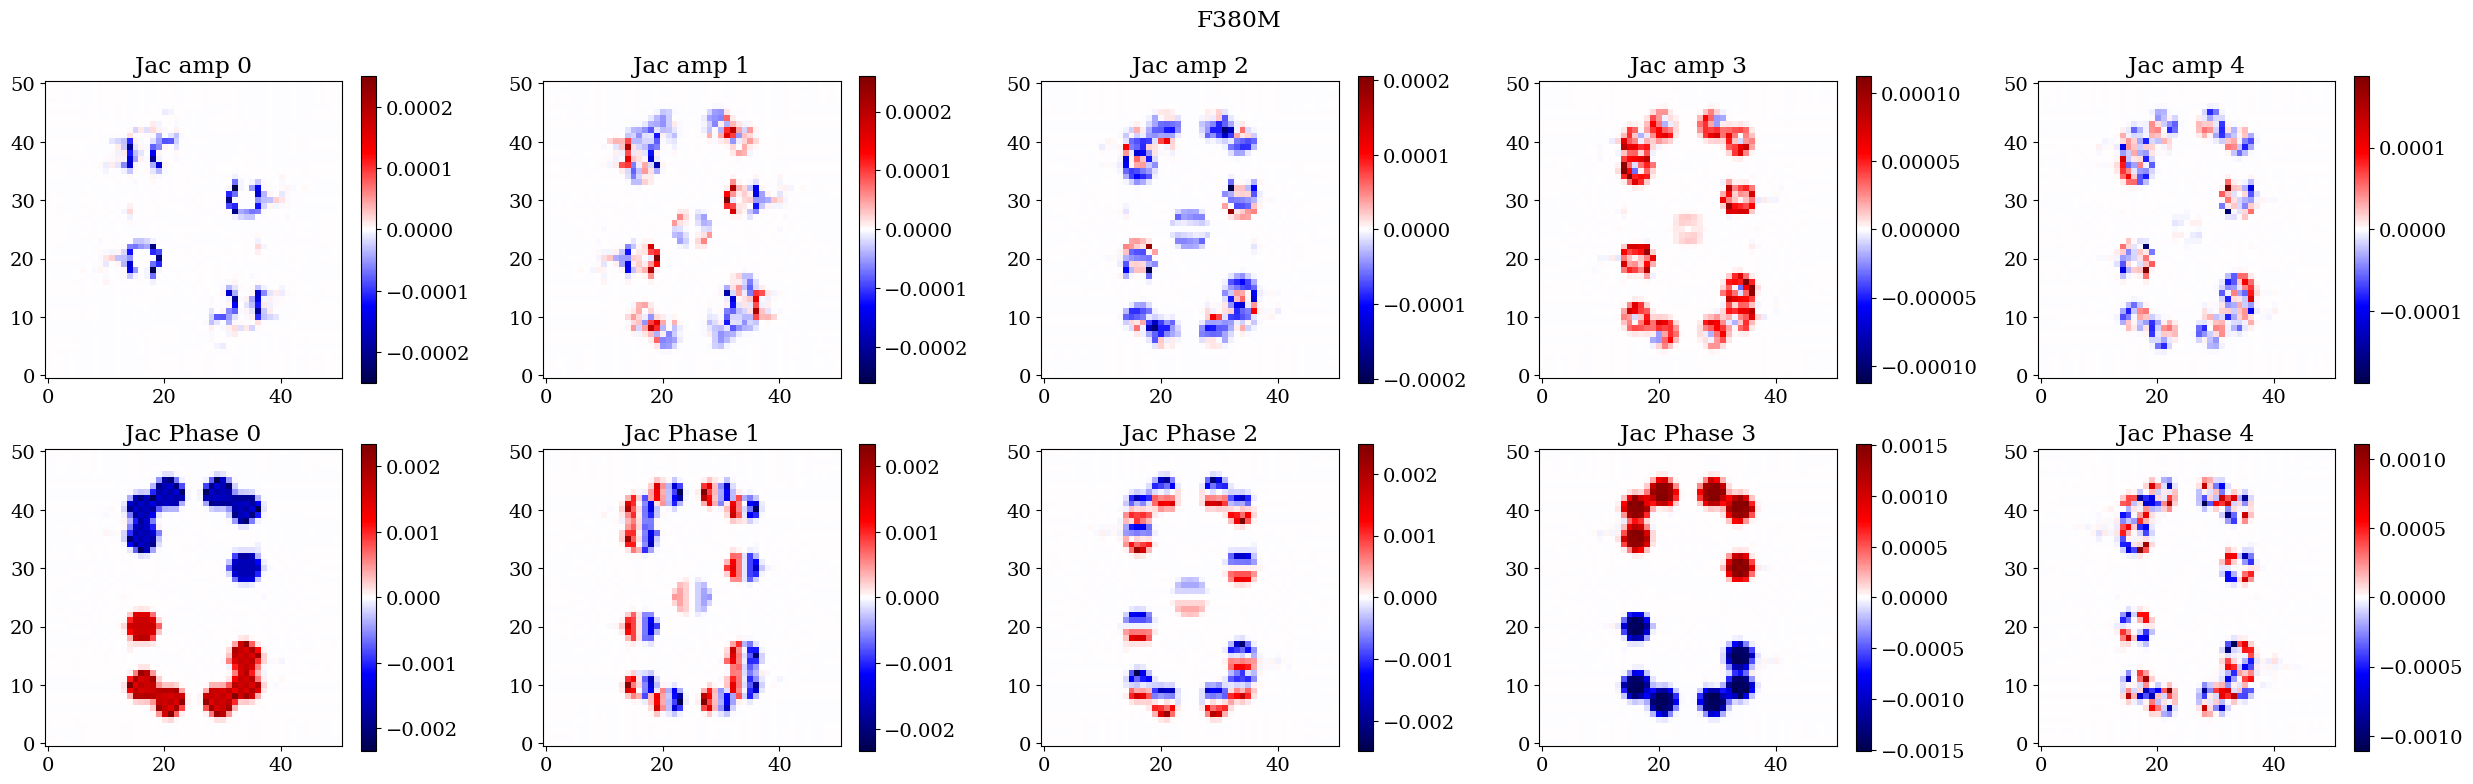

In [7]:
for filt in filters[:1]:
    lat_amp_Js = kernel_outputs[filt]["J_mats"]["amplitudes"]
    lat_phase_Js = kernel_outputs[filt]["J_mats"]["phases"]

    plt.figure(figsize=(25, 8))
    plt.suptitle(filt)
    for i in range(5):
        log_amp, phase = vis_model.latent_to_im(lat_amp_Js[:, i], lat_phase_Js[:, i], filt)

        v = np.nanmax(np.abs(log_amp))
        plt.subplot(2, 5, i + 1)
        plt.title(f"Jac amp {i}")
        plt.imshow(log_amp, seismic, vmin=-v, vmax=v)
        plt.colorbar()

        v = np.nanmax(np.abs(phase))
        plt.subplot(2, 5, i + 6)
        plt.title(f"Jac Phase {i}")
        plt.imshow(phase, seismic, vmin=-v, vmax=v)
        plt.colorbar()

    plt.tight_layout()
    plt.show()

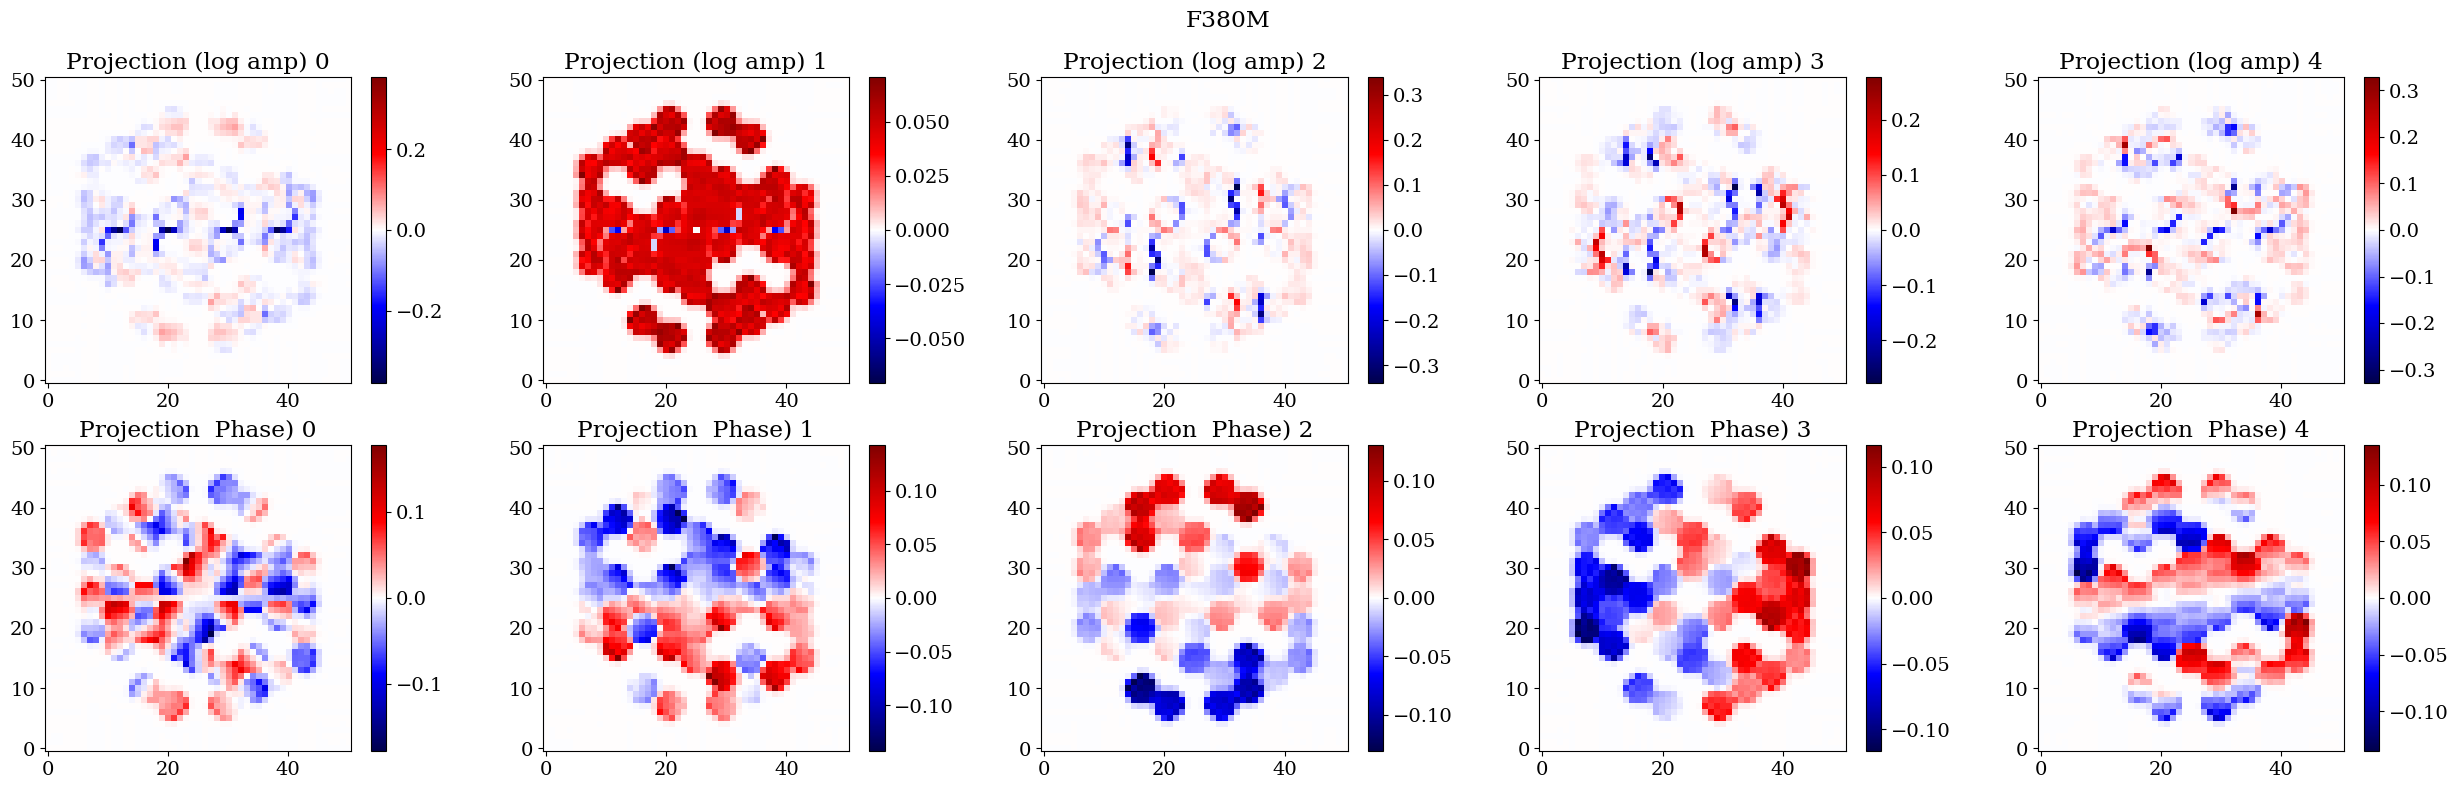

In [8]:
for filt in filters[:1]:
    amp_vecs = kernel_outputs[filt]["proj_mats"]["amplitudes"]
    phase_vecs = kernel_outputs[filt]["proj_mats"]["phases"]

    plt.figure(figsize=(25, 8))
    plt.suptitle(filt)
    for i in range(5):
        log_amp, phase = vis_model.latent_to_im(amp_vecs[i], phase_vecs[i], filt)

        v = np.nanmax(np.abs(log_amp))
        plt.subplot(2, 5, i + 1)
        plt.title(f"Projection (log amp) {i}")
        plt.imshow(log_amp, seismic, vmin=-v, vmax=v)
        plt.colorbar()

        v = np.nanmax(np.abs(phase))
        plt.subplot(2, 5, i + 6)
        plt.title(rf"Projection  Phase) {i}")
        plt.imshow(phase, seismic, vmin=-v, vmax=v)
        plt.colorbar()

    plt.tight_layout()
    plt.show()

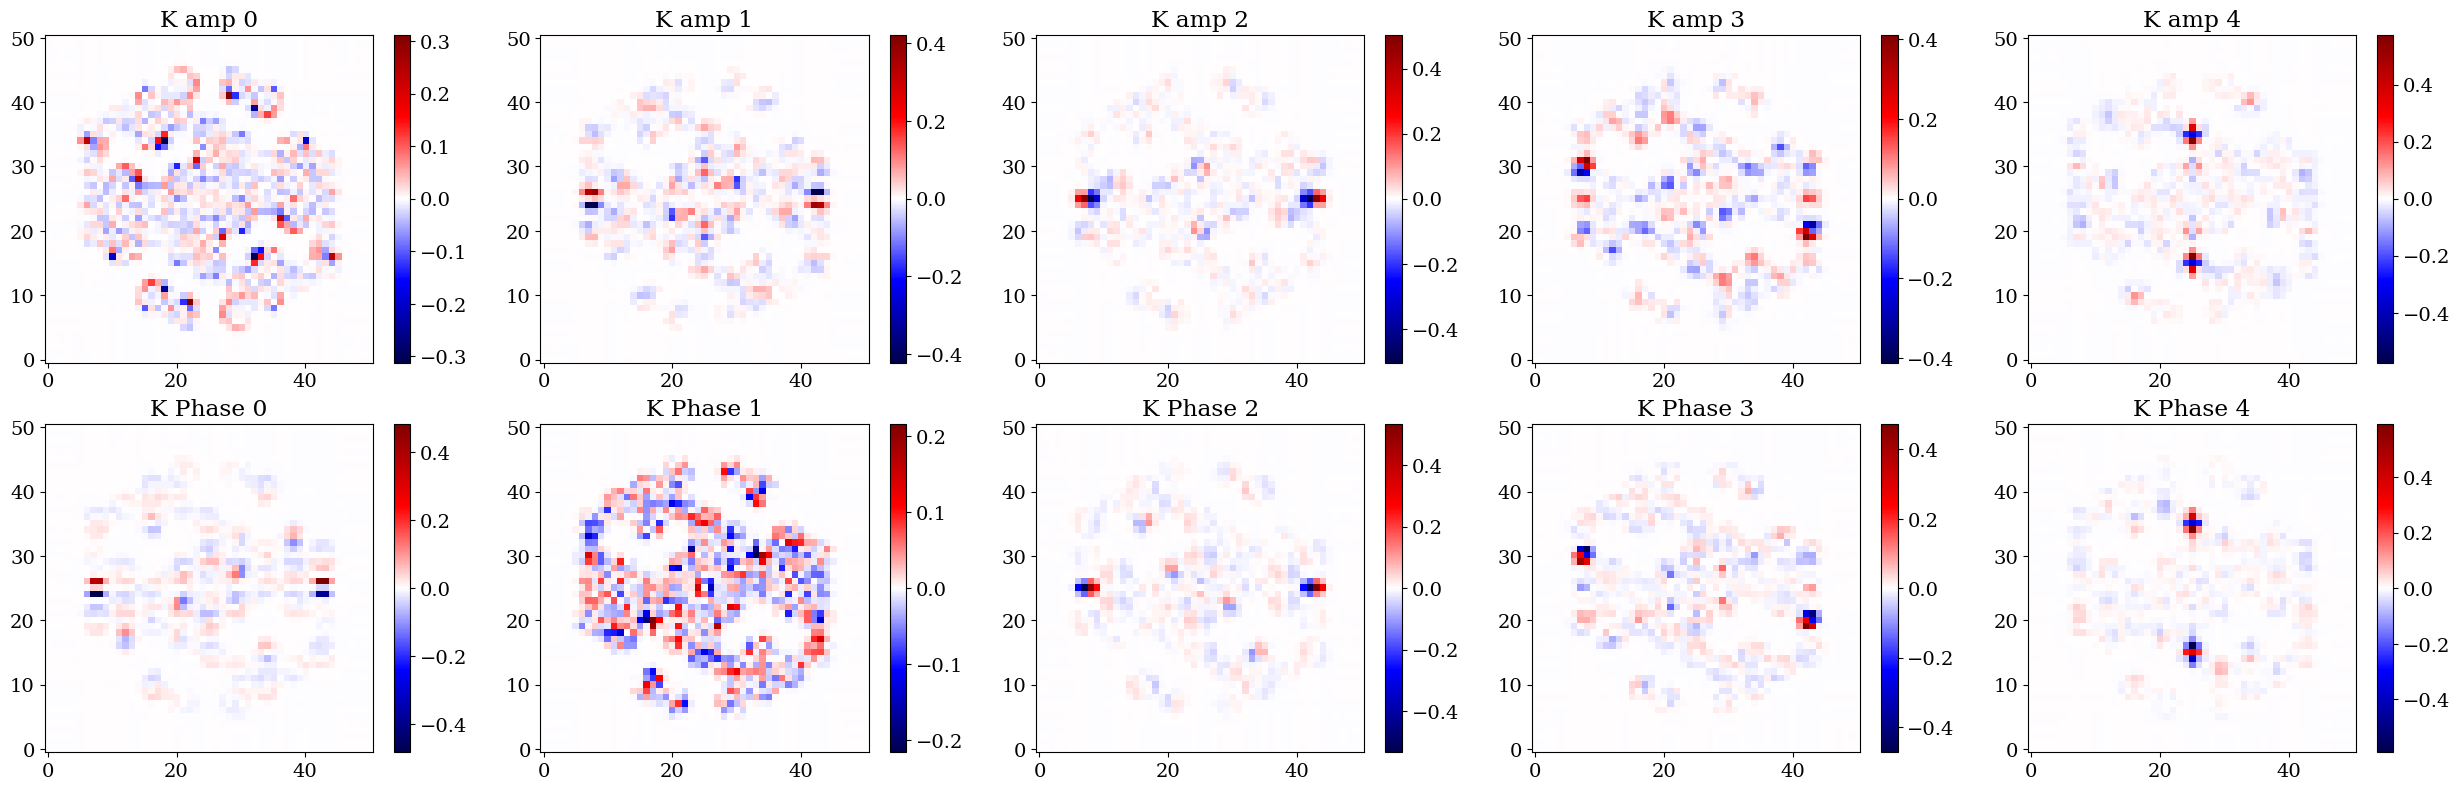

In [9]:
for filt in filters[:1]:

    amp_vecs = kernel_outputs[filt]["kernel_mats"]["amplitudes"]
    phase_vecs = kernel_outputs[filt]["kernel_mats"]["phases"]

    plt.figure(figsize=(25, 8))
    for i in range(5):
        log_amp, phase = vis_model.latent_to_im(amp_vecs[i], phase_vecs[i], filt)

        v = np.nanmax(np.abs(log_amp))
        plt.subplot(2, 5, i + 1)
        plt.title(f"K amp {i}")
        plt.imshow(log_amp, seismic, vmin=-v, vmax=v)
        plt.colorbar()

        v = np.nanmax(np.abs(phase))
        plt.subplot(2, 5, i + 6)
        plt.title(f"K Phase {i}")
        plt.imshow(phase, seismic, vmin=-v, vmax=v)
        plt.colorbar()

    plt.tight_layout()
    plt.show()

# Calibrate the Kernel visibilities

In [ ]:
from amigo.stats import orthogonalise, build_disco
from amigo.vis_calibration import get_mean_wavelength, average_vis_fits, calibrate_vis

# Get the calibrator and science stars
cal_stars = list(set([vals["star"] for vals in fit.values() if vals["calibrator"]]))
sci_stars = list(set([vals["star"] for vals in fit.values() if not vals["calibrator"]]))
stars = sci_stars + cal_stars


# Populate the fit dict with the extra values we need
for key, vals in fit.items():
    filt = vals["filter"]
    amp_K = kernel_outputs[filt]["kernel_mats"]["amplitudes"]
    phase_K = kernel_outputs[filt]["kernel_mats"]["phases"]

    full_cov = np.linalg.inv(vals["fishers"])
    amp_cov = full_cov[:n_basis, :n_basis]
    phase_cov = full_cov[n_basis:, n_basis:]

    vals["amp_cov"] = amp_cov
    vals["phase_cov"] = phase_cov
    vals["K_amp"] = np.dot(amp_K, vals["amplitudes"])
    vals["K_phase"] = np.dot(phase_K, vals["phases"])
    vals["K_amp_cov"] = np.dot(amp_K, np.dot(amp_cov, np.linalg.pinv(amp_K)))
    vals["K_phase_cov"] = np.dot(phase_K, np.dot(phase_cov, np.linalg.pinv(phase_K)))

    # Get the spectrally weighted wavelengths
    wavels, filt_weights = optics.filters[filt]
    vals["wavel"] = get_mean_wavelength(wavels, filt_weights, vals["spectra"])


# Average over the multiple exposures
vis_outputs = {}
for i, filt in enumerate(filters):
    for is_cal in [True, False]:

        # Get the list of fits to the right star and filter
        stars_in = cal_stars if is_cal else sci_stars
        star_type = "cal" if is_cal else "sci"
        vis_fits = [vals for vals in fit.values() if vals["star"] in stars_in and vals["filter"] == filt]

        # Ensure we actually have fits to this star/filter
        if len(vis_fits) == 0:
            continue

        # Average the fits
        vis_outputs[f"{star_type}_{filt}"] = average_vis_fits(vis_fits)

# Calibrate the outputs
cal_vis_outputs = {}
for i, filt in enumerate(filters):
    sci_key = f"sci_{filt}"
    cal_key = f"cal_{filt}"
    keys = vis_outputs.keys()

    # Ensure we have both the science and calibrator keys
    if sci_key not in keys or cal_key not in keys:
        continue

    # Make sure we aren't averaging over roll angles
    parang_std = vis_outputs[sci_key]["parangs"].std(0)
    assert parang_std < 0.1

    # Calibrate the visibilities
    k_cal_vis_dict = calibrate_vis(vis_outputs, filt, kernel=True)
    cal_vis_dict = calibrate_vis(vis_outputs, filt, kernel=False)

    # Projection matrices
    V_amp = vis_model.V_amp[filt]
    V_phase = vis_model.V_phase[filt]
    K_amp_op = kernel_outputs[filt]["kernel_mats"]["amplitudes"]
    K_phase_op = kernel_outputs[filt]["kernel_mats"]["phases"]

    # Orthogonalise the visibilities
    K_vis = k_cal_vis_dict["K_vis"]
    K_phi = k_cal_vis_dict["K_phi"]
    K_vis_cov = k_cal_vis_dict["K_vis_cov"]
    K_phi_cov = k_cal_vis_dict["K_phi_cov"]

    # Orthogonalise the kernel visibilities
    o_vis, o_vis_cov, o_vis_mat, o_vis_eigv = orthogonalise(K_vis, K_vis_cov)
    o_phi, o_phi_cov, o_phi_mat, o_phi_eigv = orthogonalise(K_phi, K_phi_cov)

    # Build the disco matrices
    disco_vis_mat = build_disco(V_amp, K_amp_op, o_vis_mat)
    disco_phi_mat = build_disco(V_phase, K_phase_op, o_phi_mat)

    # Save the Delay Invariant Subspace of Calibrated Observables (DISCOs)
    o_cal_vis_dict = {
        "O_vis": o_vis,
        "O_phi": o_phi,
        "O_vis_cov": o_vis_cov,
        "O_phi_cov": o_phi_cov,
        "O_vis_mat": o_vis_mat,
        "O_phi_mat": o_phi_mat,
        "O_vis_eigv": o_vis_eigv,
        "O_phi_eigv": o_phi_eigv,
        "disco_vis_mat": disco_vis_mat,
        "disco_phi_mat": disco_phi_mat,
    }

    # uv coordinates
    parang = vis_outputs[sci_key]["parangs"].mean(0)
    wavel = vis_outputs[sci_key]["wavels"].mean(0)

    # Get the coordinates
    n = vis_model.n_knots**2 // 2
    u, v = vis_model.otf_coords.reshape(2, -1)[:, :n]
    u, v = dlu.rotate_coords(np.array([u, -v]), -dlu.deg2rad(parang))

    sci_outputs = {
        "u": u,
        "v": v,
        "vis_mat": V_amp,
        "phi_mat": V_phase,
        "K_vis_mat": K_amp_op,
        "K_phi_mat": K_phase_op,
        "parang": parang,
        "wavel": wavel,
    }

    cal_vis_dict = {**sci_outputs, **o_cal_vis_dict, **k_cal_vis_dict, **cal_vis_dict}
    cal_vis_outputs[filt] = cal_vis_dict


np.save(f"{file_path}/results/{program}/cal_vis", cal_vis_outputs, allow_pickle=True)

/var/folders/28/6s47s91d14ldjdrljs4d1hxw0000gn/T/ipykernel_92857/3362020886.py:61: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


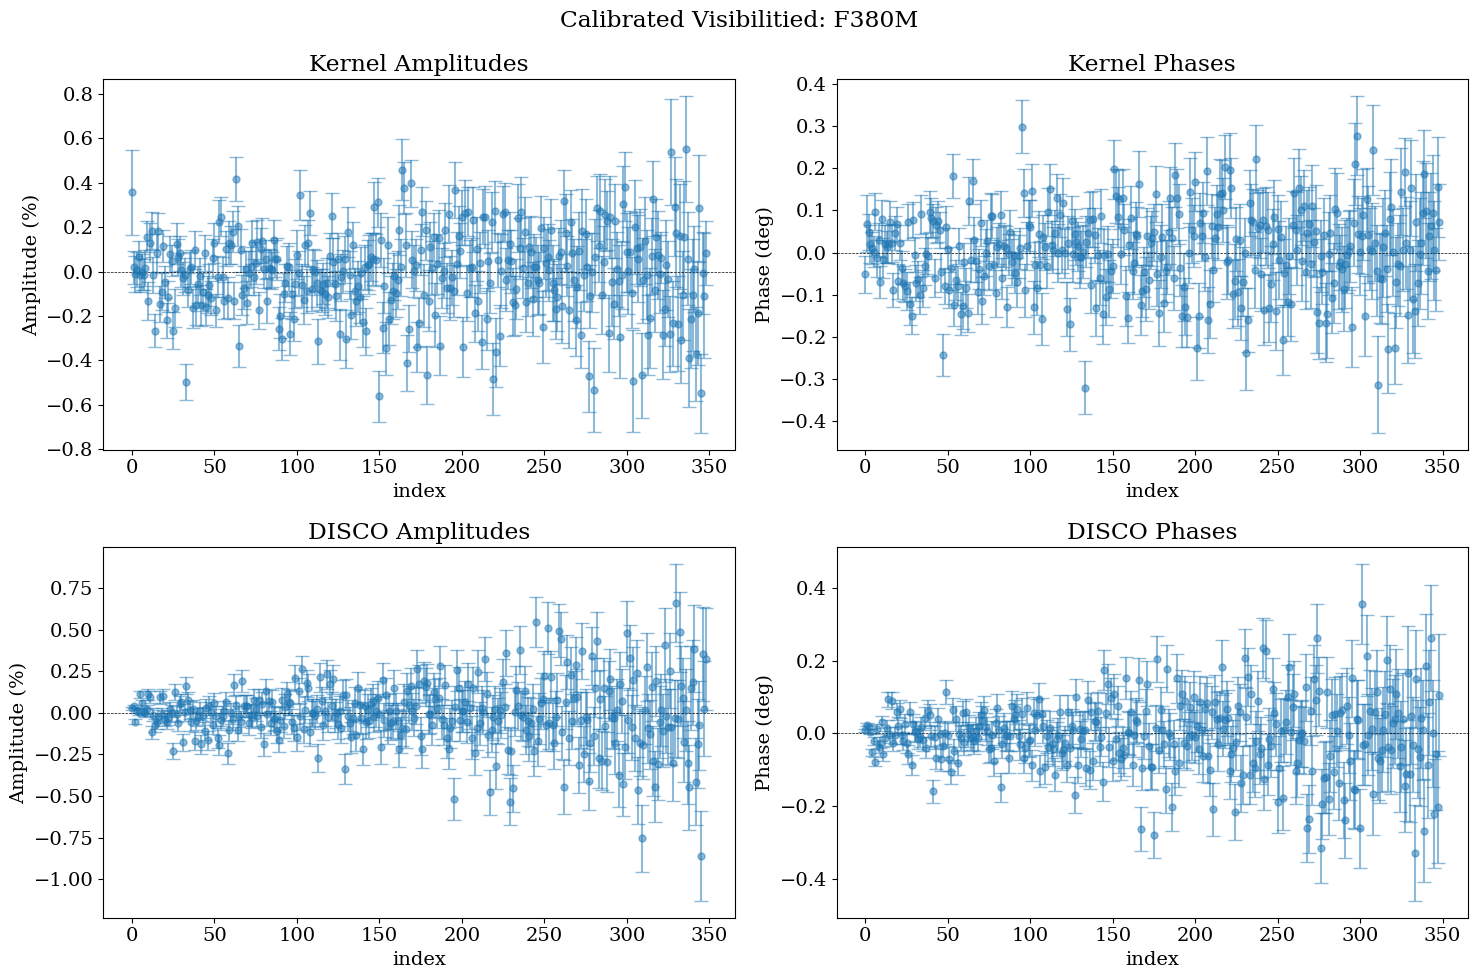

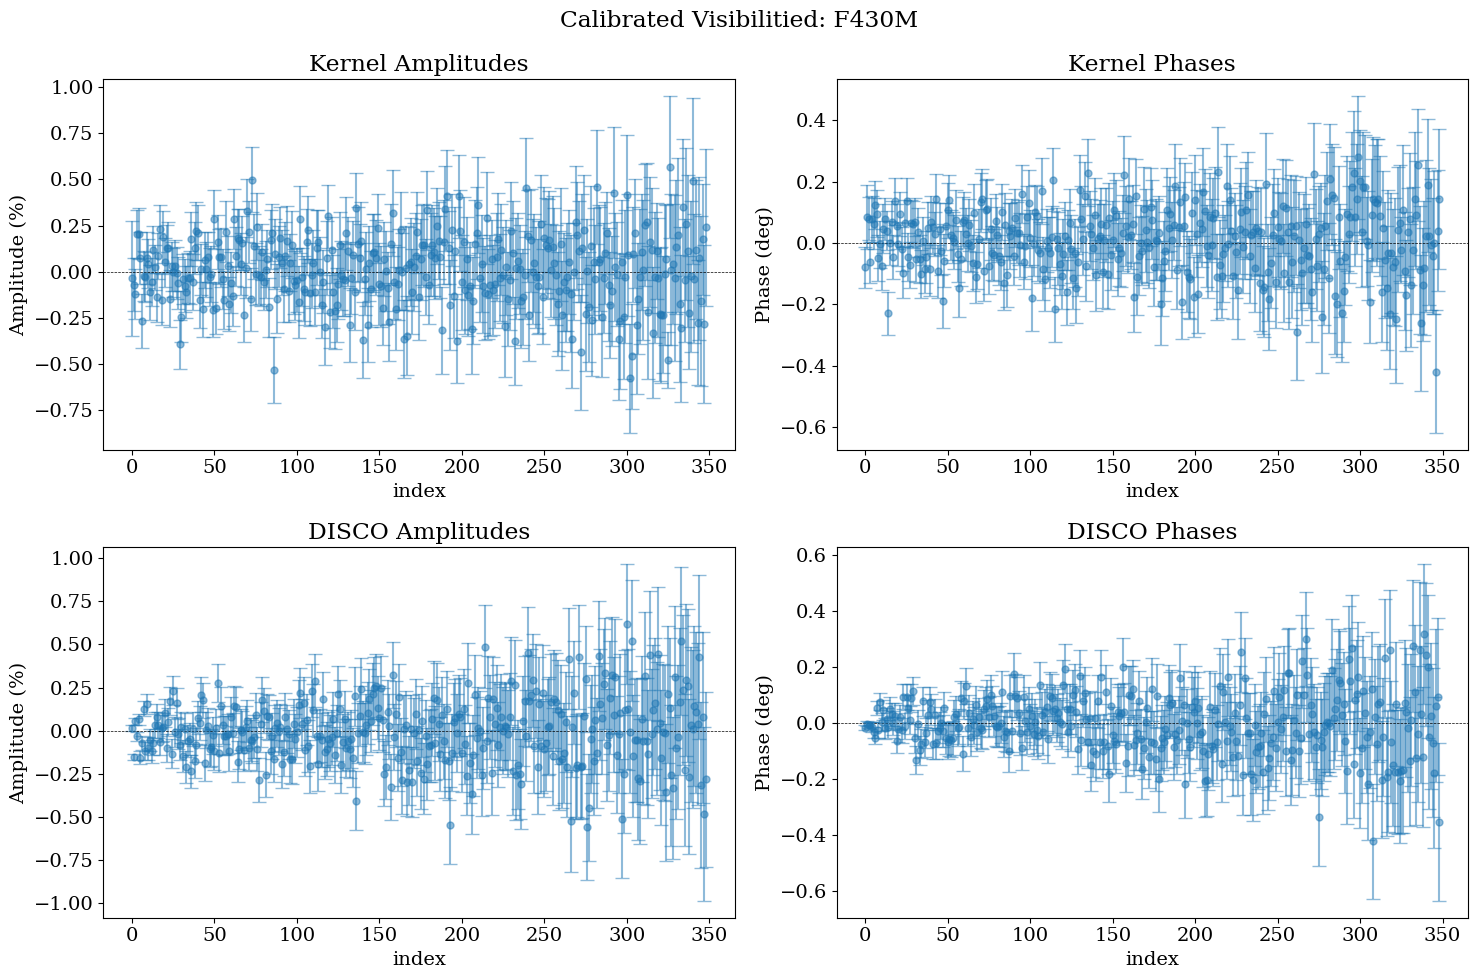

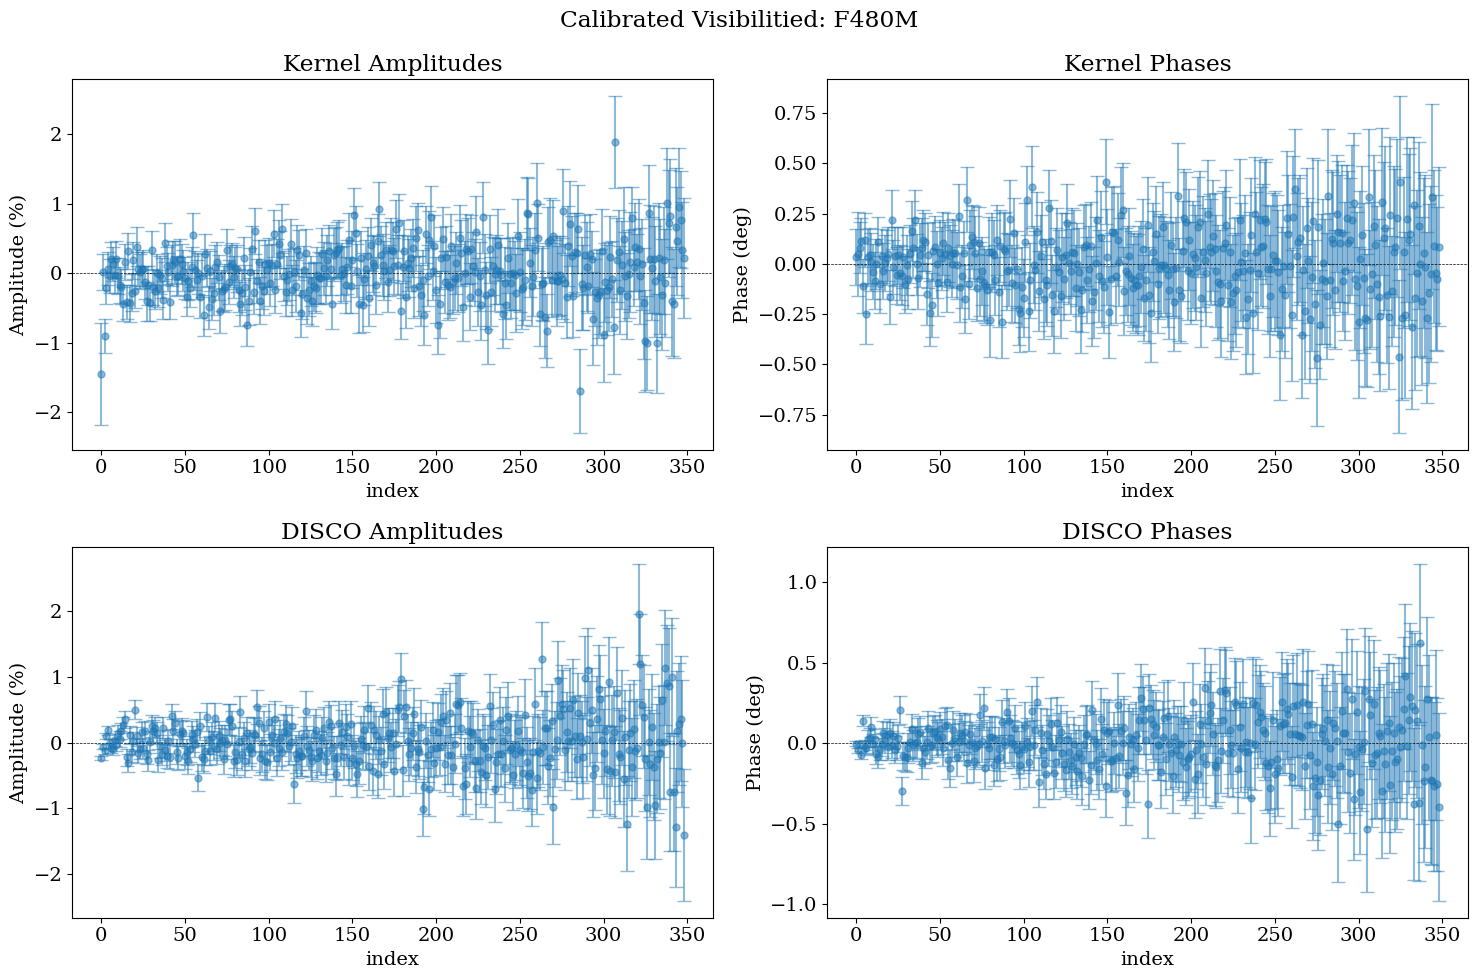

In [14]:
for filt in filters:
    if filt not in cal_vis_outputs.keys():
        continue

    K_amp = cal_vis_outputs[filt]["K_vis"]
    K_phase = cal_vis_outputs[filt]["K_phi"]
    K_amp_cov = cal_vis_outputs[filt]["K_vis_cov"]
    K_phase_cov = cal_vis_outputs[filt]["K_phi_cov"]

    O_amp = cal_vis_outputs[filt]["O_vis"]
    O_phase = cal_vis_outputs[filt]["O_phi"]
    O_amp_cov = cal_vis_outputs[filt]["O_vis_cov"]
    O_phase_cov = cal_vis_outputs[filt]["O_phi_cov"]

    # Get the errors
    K_amp_err = np.sqrt(np.diag(K_amp_cov))
    K_phase_err = np.sqrt(np.diag(K_phase_cov))
    O_amp_err = np.sqrt(np.diag(O_amp_cov))
    O_phase_err = np.sqrt(np.diag(O_phase_cov))

    # Scale to appropriate units
    K_amp = 100 * (np.exp(K_amp) - 1)
    K_phase = dlu.rad2deg(K_phase)
    K_amp_err = 100 * (np.exp(K_amp_err) - 1)
    K_phase_err = dlu.rad2deg(K_phase_err)

    O_amp = 100 * (np.exp(O_amp) - 1)
    O_phase = dlu.rad2deg(O_phase)
    O_amp_err = 100 * (np.exp(O_amp_err) - 1)
    O_phase_err = dlu.rad2deg(O_phase_err)

    inds = np.arange(len(K_phase))

    fig = plt.figure(figsize=(15, 10))
    fig.suptitle(f"Calibrated Visibilitied: {filt}")

    axes = fig.subplot_mosaic(
        [
            ["K_amp", "K_phase"],
            ["O_amp", "O_phase"],
        ],
    )

    #
    axes["K_amp"].errorbar(inds, K_amp, yerr=K_amp_err, alpha=0.5, label=filt, marker="o", capsize=5, ms=5, ls='')
    axes["K_phase"].errorbar(inds, K_phase, yerr=K_phase_err, alpha=0.5, label=filt, marker="o", capsize=5, ms=5, ls='')
    axes["O_amp"].errorbar(inds, O_amp, yerr=O_amp_err, alpha=0.5, label=filt, marker="o", capsize=5, ms=5, ls='')
    axes["O_phase"].errorbar(inds, O_phase, yerr=O_phase_err, alpha=0.5, label=filt, marker="o", capsize=5, ms=5, ls='')

    axes["K_amp"].axhline(0, color="k", ls="--", lw=0.5)
    axes["K_phase"].axhline(0, color="k", ls="--", lw=0.5)
    axes["O_amp"].axhline(0, color="k", ls="--", lw=0.5)
    axes["O_phase"].axhline(0, color="k", ls="--", lw=0.5)

    axes["K_amp"].set(ylabel="Amplitude (%)", xlabel="index", title="Kernel Amplitudes")
    axes["K_phase"].set(ylabel="Phase (deg)", xlabel="index", title="Kernel Phases")
    axes["O_amp"].set(ylabel="Amplitude (%)", xlabel="index", title="DISCO Amplitudes")
    axes["O_phase"].set(ylabel="Phase (deg)", xlabel="index", title="DISCO Phases")

    fig.tight_layout()
    fig.show()

(51, 51)


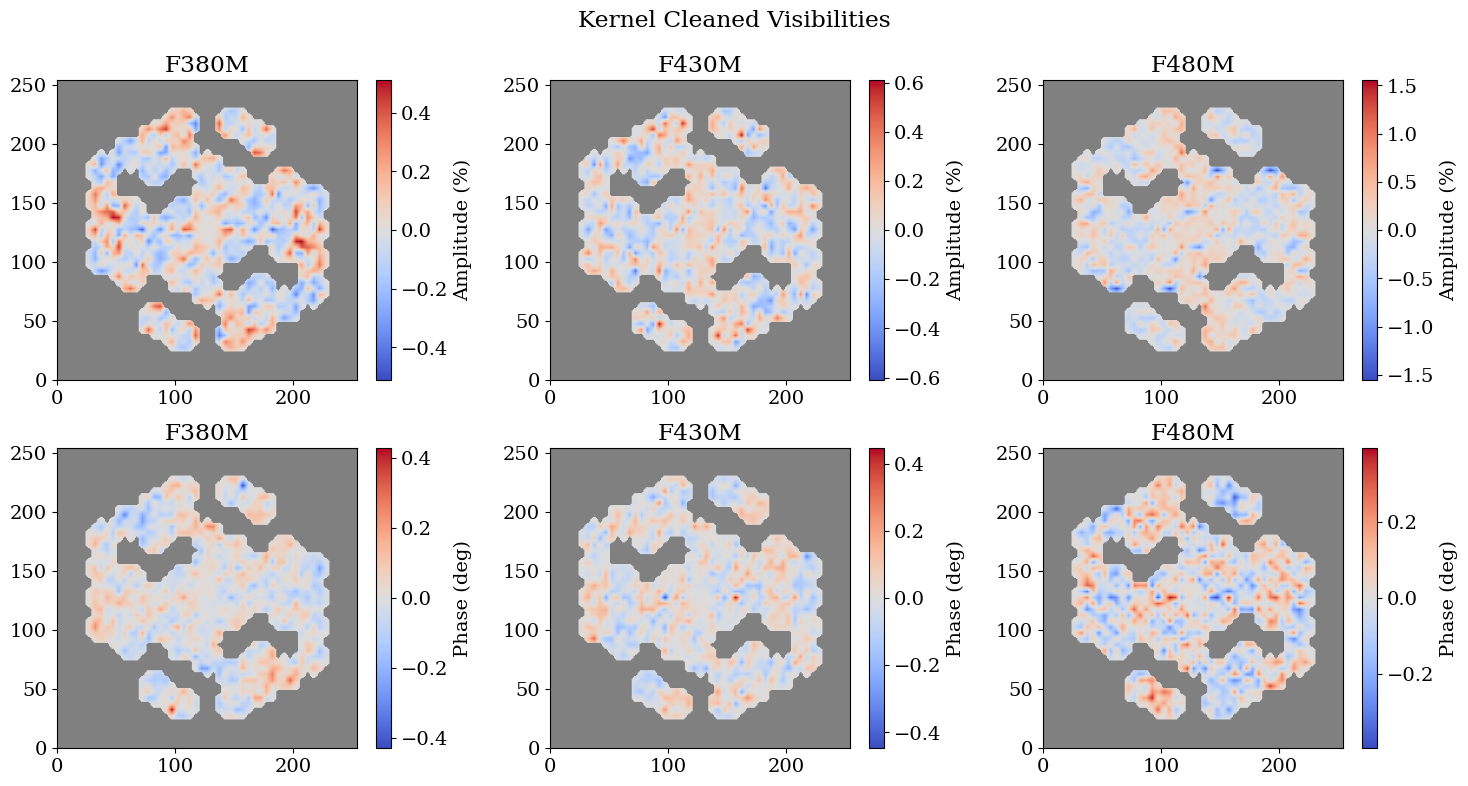

In [12]:
from amigo.misc import interp
from jax.scipy.signal import correlate
from amigo.vis_models import vis_to_im

# mask = optics.pupil_mask.calc_mask(optics.wf_npixels, optics.diameter)
mask = optics.pupil_mask.transmission
mask = dlu.downsample(mask, 8, mean=True)
splodges = correlate(mask, mask, method="fft")
splodges /= splodges.max()
splodges = dlu.downsample(splodges, 5, mean=False)
otf_mask = (splodges > 0.25).astype(float)

print(otf_mask.shape)


plt.figure(figsize=(15, 8))
plt.suptitle("Kernel Cleaned Visibilities")
for i, filt in enumerate(cal_vis_outputs.keys()):
    K_vis = cal_vis_outputs[filt]["K_vis"]
    K_phi = cal_vis_outputs[filt]["K_phi"]
    K_vis_mat = cal_vis_outputs[filt]["K_vis_mat"]
    K_phi_mat = cal_vis_outputs[filt]["K_phi_mat"]
    vis_mat = cal_vis_outputs[filt]["vis_mat"]
    phi_mat = cal_vis_outputs[filt]["phi_mat"]

    vis = np.dot(np.linalg.pinv(K_vis_mat), K_vis)
    phi = np.dot(np.linalg.pinv(K_phi_mat), K_phi)

    vis_pix = np.dot(vis, vis_mat)
    phi_pix = np.dot(phi, phi_mat)

    log_amps, phases = vis_to_im(vis_pix, phi_pix, (51, 51))

    knots = dlu.pixel_coords(51, 2)
    samples = dlu.pixel_coords(255, 2)
    log_amps = interp(log_amps, knots, samples)
    phases = interp(phases, knots, samples)


    full_otf = interp(otf_mask, knots, samples)
    log_amps = np.where(full_otf > 0.25, log_amps, np.nan)
    phases = np.where(full_otf > 0.25, phases, np.nan)

    amp = 100 * (np.exp(log_amps) - 1)
    phase = dlu.rad2deg(phases)

    v = np.nanmax(np.abs(amp))
    plt.subplot(2, 3, i + 1)
    plt.title(f"{filt}")
    plt.imshow(amp, coolwarm, vmin=-v, vmax=v)
    plt.colorbar(label="Amplitude (%)")

    v = np.nanmax(np.abs(phase))
    plt.subplot(2, 3, i + 4)
    plt.title(f"{filt}")
    plt.imshow(phase, coolwarm, vmin=-v, vmax=v)
    plt.colorbar(label="Phase (deg)")

plt.tight_layout()
plt.show()

(51, 51)


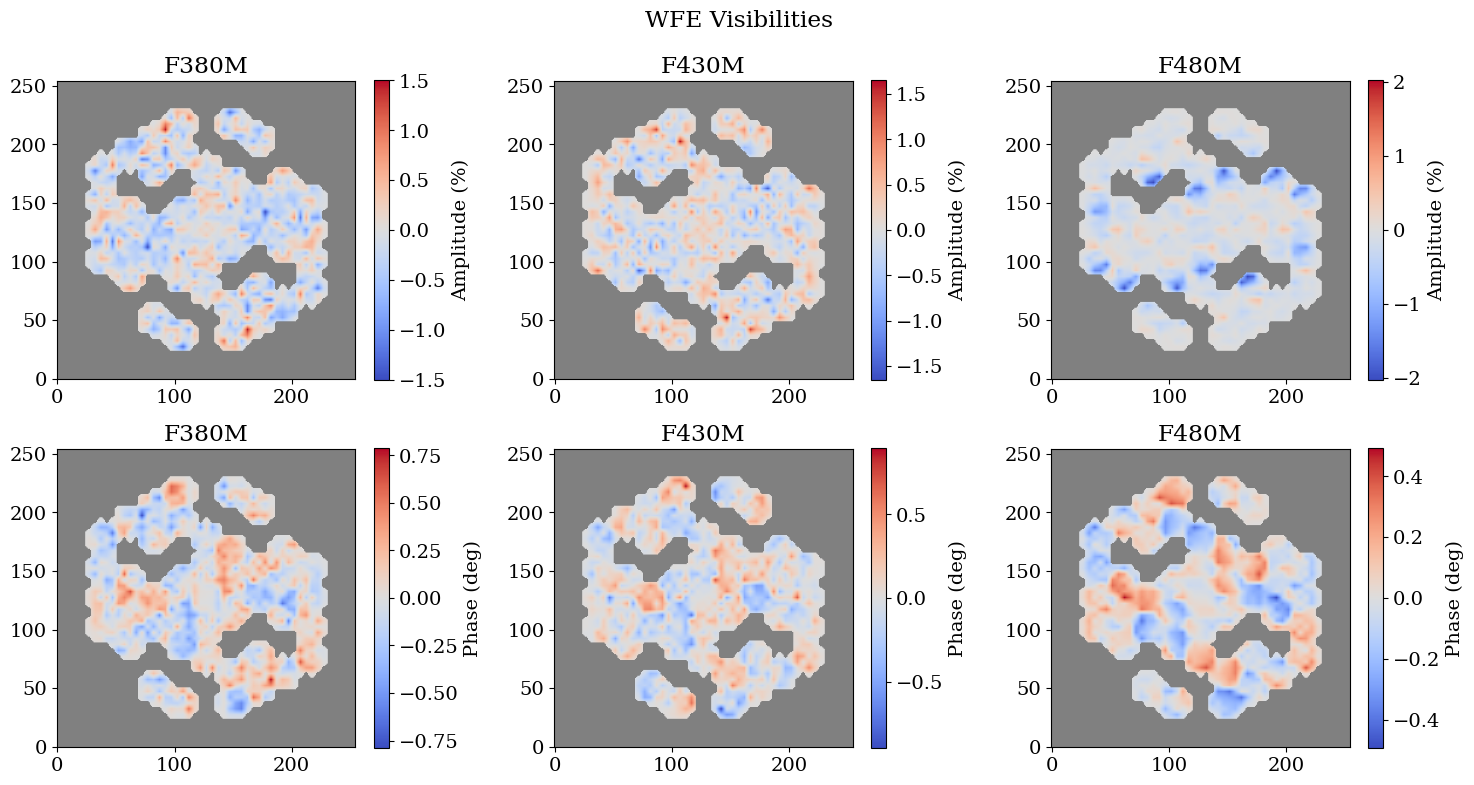

In [13]:
from amigo.misc import interp

from jax.scipy.signal import correlate

# mask = optics.pupil_mask.calc_mask(optics.wf_npixels, optics.diameter)
mask = optics.pupil_mask.transmission
mask = dlu.downsample(mask, 8, mean=True)
splodges = correlate(mask, mask, method="fft")
splodges /= splodges.max()
splodges = dlu.downsample(splodges, 5, mean=False)
otf_mask = (splodges > 0.25).astype(float)

print(otf_mask.shape)


plt.figure(figsize=(15, 8))
plt.suptitle("WFE Visibilities")
for i, filt in enumerate(cal_vis_outputs.keys()):
    raw_vis = cal_vis_outputs[filt]["vis"]
    raw_phi = cal_vis_outputs[filt]["phi"]

    #
    vis = cal_vis_outputs[filt]["vis"]
    phi = cal_vis_outputs[filt]["phi"]
    vis_mat = cal_vis_outputs[filt]["vis_mat"]
    phi_mat = cal_vis_outputs[filt]["phi_mat"]

    #
    vis_mat = cal_vis_outputs[filt]["vis_mat"]
    phi_mat = cal_vis_outputs[filt]["phi_mat"]


    vis = np.dot(np.linalg.pinv(K_vis_mat), K_vis)
    phi = np.dot(np.linalg.pinv(K_phi_mat), K_phi)

    vis_pix = np.dot(raw_vis, vis_mat) - np.dot(vis, vis_mat)
    phi_pix = np.dot(raw_phi, phi_mat) - np.dot(phi, phi_mat)

    log_amps, phases = vis_to_im(vis_pix, phi_pix, (51, 51))

    knots = dlu.pixel_coords(51, 2)
    samples = dlu.pixel_coords(255, 2)
    log_amps = interp(log_amps, knots, samples)
    phases = interp(phases, knots, samples)

    full_otf = interp(otf_mask, knots, samples)
    log_amps = np.where(full_otf > 0.25, log_amps, np.nan)
    phases = np.where(full_otf > 0.25, phases, np.nan)

    amp = 100 * (np.exp(log_amps) - 1)
    phase = dlu.rad2deg(phases)

    v = np.nanmax(np.abs(amp))
    plt.subplot(2, 3, i + 1)
    plt.title(f"{filt}")
    plt.imshow(amp, coolwarm, vmin=-v, vmax=v)
    plt.colorbar(label="Amplitude (%)")

    v = np.nanmax(np.abs(phase))
    plt.subplot(2, 3, i + 4)
    plt.title(f"{filt}")
    plt.imshow(phase, coolwarm, vmin=-v, vmax=v)
    plt.colorbar(label="Phase (deg)")

plt.tight_layout()
plt.show()